# Day 5: Polymer+Water+Ions Production Simulation with GROMACS and Analysis

This notebook demonstrates how to perform a production molecular dynamics (MD) simulation of a solvated polymer system using **GROMACS**. The workflow includes the following steps:
1. **Production MD Simulation**: Perform a 10 ns simulation at constant pressure (1 bar) and temperature (300 K).
2. **Analysis Stage**: Analyze the simulation results to calculate:
   - Root Mean Squared Displacement (RMSD) of the polymer chain.
   - Radius of Gyration of the polymer chain.
   - Radial Distribution Function (RDF) for Na-Cl and Na-Os.
   - Glass Transition Temperature from simulated annealing simulations.

The notebook also includes visualization of the system and analysis results using **nglview**, **MDAnalysis**, and **matplotlib**.

---

## GROMACS Formats and Models

### GROMACS File Formats
- **`.gro`**: GROMACS coordinate file containing atomic positions and box dimensions.
- **`.top`**: Topology file describing the molecular structure, force field parameters, and system composition.
- **`.tpr`**: Binary input file for GROMACS simulations, generated by `gmx grompp`.
- **`.edr`**: Energy file containing simulation energy data.
- **`.trr`**: Full-precision trajectory file.
- **`.xtc`**: Compressed trajectory file.
- **`.log`**: Log file with simulation details.

### Models Used
- **Force Field**: AMBER03 with TIP3P water model.
- **Polymer**: Random copolymer of PEO and PET.
- **Water**: SPC/E water model.
- **Ions**: Na+ and Cl- ions for neutralization and ionic strength adjustment.

For more details, refer to the [GROMACS Lysozyme Tutorial](http://www.mdtutorials.com/gmx/lysozyme/06_equil.html).

## Step 0: Initialization

This step sets up the environment for the tutorial. It installs required Python packages, creates necessary directories, and defines reusable functions.

**Important:** Run this step only once when starting the notebook or after restarting the kernel.

In [3]:
# --- Lightweight "reset" for clean re-run ---
from IPython.display import clear_output
import importlib, os, sys

clear_output(wait=True)
importlib.invalidate_caches()

# Install required packages
!{sys.executable} -m pip install nglview parmed pandas panedr MDAnalysis > /dev/null

import numpy as np
import nglview as nv
import parmed as pmd
import pandas as pd
import panedr
import matplotlib.pyplot as plt
import MDAnalysis as mda


# Set fixed project root
if "PROJECT_ROOT" not in os.environ:
    os.environ["PROJECT_ROOT"] = os.path.abspath(os.getcwd())

PROJECT_ROOT = os.environ["PROJECT_ROOT"]
print("Project root:", PROJECT_ROOT)

# Create subdirectories
os.makedirs(os.path.join(PROJECT_ROOT, "simulations"), exist_ok=True)
os.makedirs(os.path.join(PROJECT_ROOT, "mdps"), exist_ok=True)
MDP_DIR = os.path.join(PROJECT_ROOT, "mdps")

# Define reusable functions
def run_command(command):
    """Runs a shell command and prints the output."""
    print(f"Executing: {command}")
    os.system(command)


def visualize_trajectory(coordinate_file, trajectory_file=None, show_box=True, box_color='orange', box_opacity=0.8):
    """
    Visualize a molecular structure or trajectory using MDAnalysis with nglview.
    Supports single-frame files (GRO, PDB, MOL2) or trajectories.
    Displays the periodic boundary box if available.

    Parameters:
        coordinate_file (str): Path to coordinate file (PDB, GRO, MOL2, etc.)
        trajectory_file (str, optional): Path to trajectory file (DCD, XTC, TRR, etc.). Default None.
        show_box (bool): Whether to display the periodic box. Default True.
        box_color (str): Color of PBC box. Default 'orange'.
        box_opacity (float): Opacity of PBC box (0.0-1.0). Default 0.3.

    Returns:
        nglview.NGLWidget: Interactive 3D view of the structure or trajectory.
    """
    # Load Universe with or without trajectory
    if trajectory_file:
        u = mda.Universe(coordinate_file, trajectory_file)
    else:
        u = mda.Universe(coordinate_file)

    # Create nglview widget
    view = nv.show_mdanalysis(u)

    # Orthographic camera
    view.camera = 'orthographic'

    # Disable fog and make atoms fully opaque
    view.stage.set_parameters(fog=False)
    for rep in view.representations:
        rep.update_params(opacity=1.0)

    # Add periodic box if requested and available
    if show_box and hasattr(u, 'dimensions') and u.dimensions is not None:
        # MDAnalysis stores dimensions as [lx, ly, lz, alpha, beta, gamma]
        a, b, c, alpha, beta, gamma = u.dimensions
        box_params = [a, b, c, alpha, beta, gamma, 0, 0, 0]
        view.add_unitcell(color=box_color, opacity=box_opacity, box=box_params)

    # Add water as spacefill (or ball+stick)
    view.add_representation('ball+stick', selection='resname SOL')

    return view


def set_simulation_directory(polymer_name, step_name):
    """
    Create and change to the simulation directory for a specific polymer and step.

    Parameters:
        polymer_name (str): Name of the polymer.
        step_name (str): Name of the simulation step (e.g., 'em', 'preeq', 'eq-nvt').

    Returns:
        str: Path to the created directory.
    """
    sim_dir = os.path.join(PROJECT_ROOT, "simulations", polymer_name, step_name)
    os.makedirs(sim_dir, exist_ok=True)
    os.chdir(sim_dir)
    print(f"Changed to simulation directory: {sim_dir}")
    return sim_dir

Project root: /Users/harish/Documents/Work_folder/MetaChem-workshops/polymermd-workshop/Day4,5-gmx-md-simulation-analysis


# Production Simulations (NPT at 300 K)

### Purpose
Perform a production MD simulation at constant pressure (1 bar) and temperature (300 K) to study the polymer system's behavior over time.

### Key Parameters
- **Integrator**: Leap-frog MD integrator.
- **Simulation Time**: 10 ns.
- **Temperature**: 300 K.

In [9]:
# Production (NPT at 300 K, 5 ns)
polymer_name = "PEO25_PET25_block"
prod_dir = set_simulation_directory(polymer_name, "prod-npt")

# Write production parameters to an MDP file (5 ns)
with open("prod-npt.mdp", "w") as f:
    f.write("""
; Production MD Parameters
; ------------------------
; This MDP file is used for production MD simulation at 300 K.

; Run parameters
integrator              = md            ; Leap-frog integrator
nsteps                  = 2500000       ; Number of steps (5 ns)
dt                      = 0.002         ; Time step (ps)

; Output control
nstxout-compressed      = 1000          ; Write compressed coordinates every 2 ps
nstenergy               = 1000          ; Write energies every 2 ps
nstlog                  = 1000          ; Write log file every 2 ps

; Bonded parameters
constraints             = h-bonds       ; Constrain bonds involving hydrogen
constraint_algorithm    = lincs         ; LINCS algorithm for constraints

; Nonbonded settings
cutoff-scheme           = Verlet        ; Buffered neighbor searching
rlist                   = 1.2           ; Short-range neighbor list cutoff (nm)
rvdw                    = 1.2           ; Short-range van der Waals cutoff (nm)

; Electrostatics settings
coulombtype             = PME           ; Particle Mesh Ewald for long-range electrostatics
rcoulomb                = 1.2           ; Short-range electrostatic cutoff (nm)

; Temperature coupling
tcoupl                  = V-rescale     ; Velocity-rescaling thermostat
tc-grps                 = System        ; Coupling group (entire system)
tau_t                   = 0.1           ; Time constant for temperature coupling (ps)
ref_t                   = 300           ; Reference temperature (K)

; Pressure coupling
pcoupl                  = Parrinello-Rahman ; Parrinello-Rahman barostat
pcoupltype              = isotropic     ; Isotropic pressure coupling
tau_p                   = 2.0           ; Time constant for pressure coupling (ps)
ref_p                   = 1.0           ; Reference pressure (bar)
compressibility         = 4.5e-5        ; Compressibility of water (bar^-1)

; Periodic boundary conditions
pbc                     = xyz           ; Periodic boundary conditions in all directions

; Velocity generation
gen_vel                 = no            ; Do not generate velocities (use velocities from equilibration)
""")

# Step 1: Generate the .tpr file
grompp_cmd = "gmx grompp -f prod-npt.mdp -c ../eq-npt/eq-npt.gro -p ../topol.top -o prod-npt.tpr -maxwarn 2"
run_command(grompp_cmd)

# Step 2: Run production MD
mdrun_cmd = "gmx mdrun -s prod-npt.tpr -deffnm prod-npt -v"
#run_command(mdrun_cmd)
print(f"Run this command in external terminal to execute production MD: \n {mdrun_cmd}")

Changed to simulation directory: /Users/harish/Documents/Work_folder/MetaChem-workshops/polymermd-workshop/Day4-gmx-md-formats/simulations/PEO25_PET25_block/prod-npt
Executing: gmx grompp -f prod-npt.mdp -c ../eq-npt/eq-npt.gro -p ../topol.top -o prod-npt.tpr -maxwarn 2
Setting the LD random seed to -604574209

Generated 78 of the 78 non-bonded parameter combinations

Generated 78 of the 78 1-4 parameter combinations

Excluding 3 bonded neighbours molecule type 'system1'

turning H bonds into constraints...

Excluding 2 bonded neighbours molecule type 'SOL'

turning H bonds into constraints...

Excluding 1 bonded neighbours molecule type 'NA'

turning H bonds into constraints...

Excluding 1 bonded neighbours molecule type 'CL'

turning H bonds into constraints...

Taking velocities from '../eq-npt/eq-npt.gro'
Analysing residue names:
There are:    30      Other residues
There are:   804      Water residues
There are:   196        Ion residues
Analysing residues not classified as Prote

                :-) GROMACS - gmx grompp, 2025.2-conda_forge (-:

Executable:   /Users/harish/miniconda3/envs/polymer_md/bin.ARM_NEON_ASIMD/gmx
Data prefix:  /Users/harish/miniconda3/envs/polymer_md
Working dir:  /Users/harish/Documents/Work_folder/MetaChem-workshops/polymermd-workshop/Day4-gmx-md-formats/simulations/PEO25_PET25_block/prod-npt
Command line:
  gmx grompp -f prod-npt.mdp -c ../eq-npt/eq-npt.gro -p ../topol.top -o prod-npt.tpr -maxwarn 2

Generating 1-4 interactions: fudge = 0.5
Number of degrees of freedom in T-Coupling group System is 7634.00

GROMACS reminds you: ""Everything organic and natural is good" - ignoring the fact that organic natural substances include arsenic and poo and crocodiles. And everything chemical is bad, ignoring the fact that... everything is chemicals." (Tim Minchin)



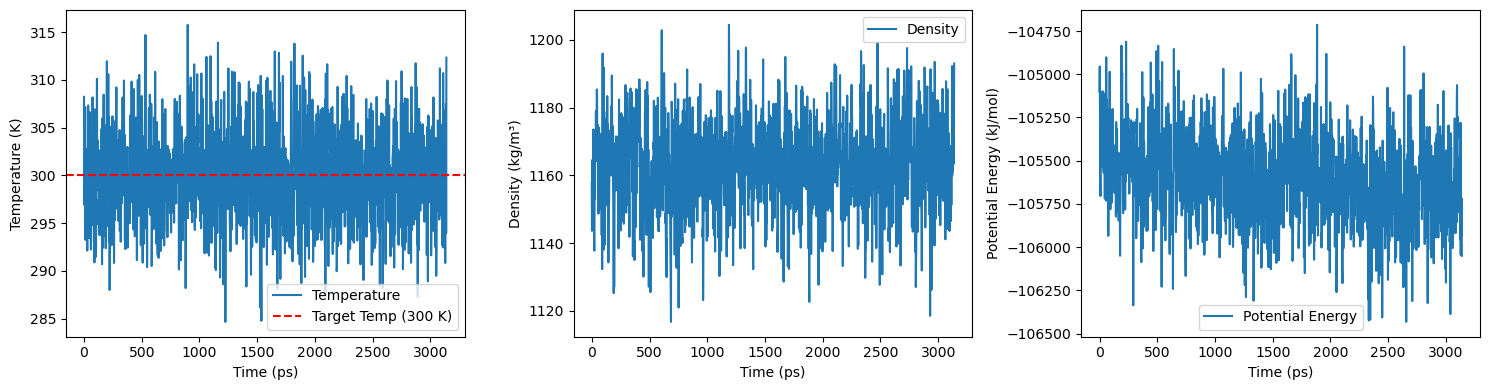

In [8]:
# Plot temperature and volume
npt_edr = os.path.join(prod_dir, "prod-npt.edr")
df = panedr.edr_to_df(npt_edr)

plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.plot(df["Time"], df["Temperature"], label="Temperature")
plt.axhline(300, color="red", linestyle="--", label="Target Temp (300 K)")
plt.xlabel("Time (ps)")
plt.ylabel("Temperature (K)")
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(df["Time"], df["Density"], label="Density")
plt.xlabel("Time (ps)")
plt.ylabel("Density (kg/m³)")
plt.legend()
plt.subplot(1, 3, 3)
plt.plot(df["Time"], df["Potential"], label="Potential Energy")
plt.xlabel("Time (ps)")
plt.ylabel("Potential Energy (kJ/mol)")
plt.legend()

plt.tight_layout()
plt.show()

## Example SLURM Script to Run GROMACS Production MD
Below is an example `sbatch` script to run both `gmx grompp` and `gmx mdrun` for a 5 ns production simulation on a SLURM-based cluster. Adjust resource requests as needed for your system.

```bash
#!/bin/bash
#SBATCH --job-name=gmx_prod
#SBATCH --output=gmx_prod.out
#SBATCH --error=gmx_prod.err
#SBATCH --ntasks=8
#SBATCH --time=06:00:00
#SBATCH --partition=compute
#SBATCH --mem=8G

module load gromacs

# Step 1: Generate the .tpr file
gmx grompp -f prod.mdp -c ../em/em.gro -p ../topol.top -o prod.tpr -maxwarn 2

# Step 2: Run production MD
gmx mdrun -s prod.tpr -deffnm prod -nt 8 -v
```

# Analysis Stage

### Purpose
Analyze the results of the production MD simulation to extract key properties of the polymer system.

### Workflow
1. **Root Mean Squared Displacement (RMSD)**: Analyze the structural stability of the polymer chain.
2. **Radius of Gyration**: Measure the compactness of the polymer chain.
3. **Radial Distribution Function (RDF)**: Study the spatial distribution of ions and polymer atoms.
4. **Glass Transition Temperature**: Analyze the temperature-dependent density changes from simulated annealing simulations.

In [10]:
# Set the directories
polymer_name = "PEO25_PET25_block"
prod_dir = set_simulation_directory(polymer_name, "prod-npt")
analysis_dir = set_simulation_directory(polymer_name, "analysis")

Changed to simulation directory: /Users/harish/Documents/Work_folder/MetaChem-workshops/polymermd-workshop/Day4-gmx-md-formats/simulations/PEO25_PET25_block/prod-npt
Changed to simulation directory: /Users/harish/Documents/Work_folder/MetaChem-workshops/polymermd-workshop/Day4-gmx-md-formats/simulations/PEO25_PET25_block/analysis


## Root Mean Squared Deviation (RMSD) of Polymer Chain

### Purpose
Calculate the RMSD of the polymer chain to analyze its structural stability over time.

### Procedure
1. Use `gmx rms` to calculate the RMSD of the polymer chain.
```bash
"gmx rms" compares two structures by computing the root mean square deviation
(RMSD), the size-independent rho similarity paramete.

Each structure from a trajectory (-f) is compared to a reference structure.
The reference structure is taken from the structure file (-s).

Used options:
 -tu     ns    #Unit for time values: fs, ps, ns, us, ms, s
 -b      1     #Time of first frame to read from trajectory (default unit ps, here time unit set to ns)        
           
````
2. It will propt you to select two groups, one for least squares fit (reference), other group for RMSD calculation. **Enter the group id's, here both are  "Group 1 (Other)" which defined whole polymer chain in the simulation box.**
3. The output should look like this.

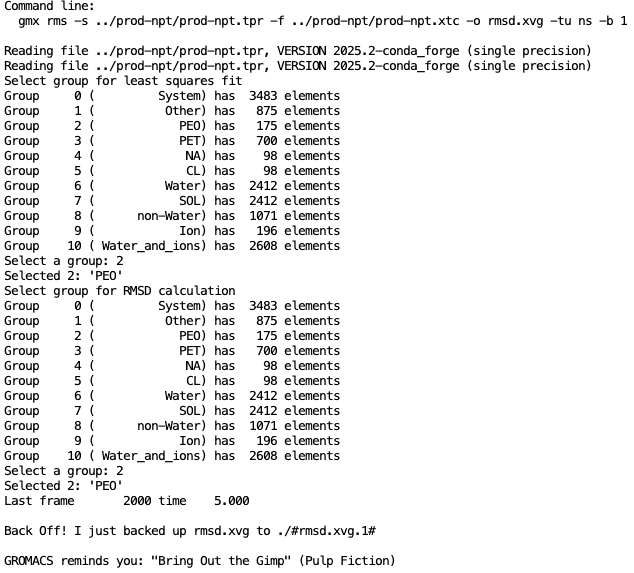

4. Plot the RMSD as a function of time saved in the **ANALYSIS_DIR/rmsd.xvg**.

In [19]:
# Calculate RMSD using gmx rms
# Production (NPT at 300 K, 5 ns)
# Set the directories
polymer_name = "PEO25_PET25_random"
analysis_dir = set_simulation_directory(polymer_name, "analysis")

rmsd_cmd = f"gmx rms -s ../prod-npt/prod-npt.tpr -f ../prod-npt/prod-npt.xtc -o rmsd.xvg -tu ns -b 0"
print(f"Run this command in external terminal in analysis directory to calculate RMSD: \n {rmsd_cmd}")

Changed to simulation directory: /Users/harish/Documents/Work_folder/MetaChem-workshops/polymermd-workshop/Day4-gmx-md-formats/simulations/PEO25_PET25_random/analysis
Run this command in external terminal in analysis directory to calculate RMSD: 
 gmx rms -s ../prod-npt/prod-npt.tpr -f ../prod-npt/prod-npt.xtc -o rmsd.xvg -tu ns -b 0


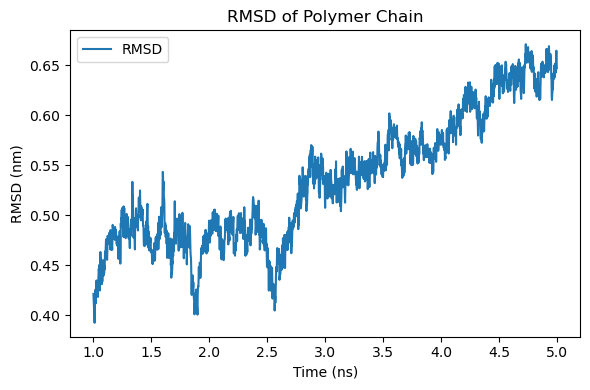

In [16]:
# Plot RMSD
rmsd_data = np.loadtxt(f"{analysis_dir}/rmsd.xvg", comments=["@", "#"])
time = rmsd_data[:, 0]  # Time (ns)
rmsd = rmsd_data[:, 1]  # RMSD (nm)

plt.figure(figsize=(6, 4))
plt.plot(time, rmsd, label="RMSD")
plt.xlabel("Time (ns)")
plt.ylabel("RMSD (nm)")
plt.title("RMSD of Polymer Chain")
plt.legend()
plt.tight_layout()
plt.show()

Changed to simulation directory: /Users/harish/Documents/Work_folder/MetaChem-workshops/polymermd-workshop/Day4-gmx-md-formats/simulations/PEO25_PET25_block/analysis
Changed to simulation directory: /Users/harish/Documents/Work_folder/MetaChem-workshops/polymermd-workshop/Day4-gmx-md-formats/simulations/PEO25_PET25_random/analysis


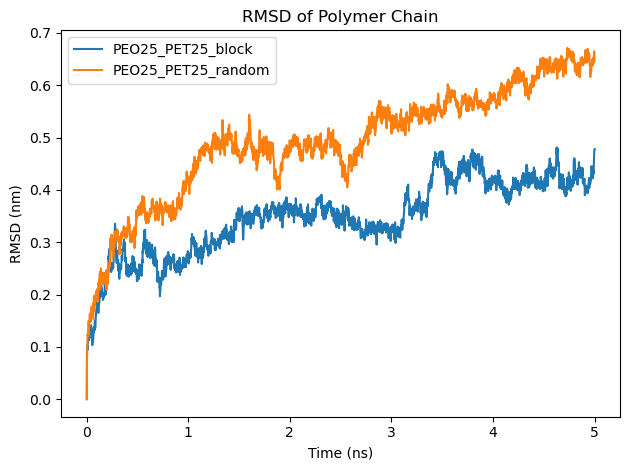

In [20]:
# Plot RMSD of both block and random co-polymers
# Looping through both the polymer names and set the directories accordingly
for polymer_name in ['PEO25_PET25_block','PEO25_PET25_random']:
    analysis_dir = set_simulation_directory(polymer_name, "analysis")
    rmsd_data = np.loadtxt(f"{analysis_dir}/rmsd.xvg", comments=["@", "#"])
    time = rmsd_data[:, 0]  # Time (ns)
    rmsd = rmsd_data[:, 1]  # RMSD (nm)
    
    plt.plot(time, rmsd, label=polymer_name)
    plt.xlabel("Time (ns)")
    plt.ylabel("RMSD (nm)")
    plt.title("RMSD of Polymer Chain")
    plt.legend()
plt.tight_layout()
plt.show()

## Radius of Gyration of Polymer Chain

### Purpose
Calculate the radius of gyration of the polymer chain to analyze its compactness over time.

### Procedure
1. Use `gmx gyrate` to calculate the radius of gyration.
```bash
   "gmx gyrate" computes the radius of gyration of a molecule and the radii of
gyration about the x-, y- and z-axes, as a function of time. The atoms are
explicitly mass weighted.
````

2. The output should look like this:

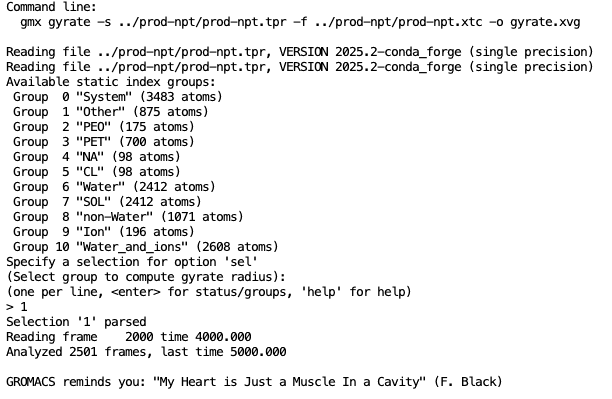

3. Plot the radius of gyration as a function of time saved in **ANALYSIS_DIR/gyrate.xyz**.

In [22]:
# Calculate Radius of Gyration using gmx gyrate
# Set the directories
polymer_name = "PEO25_PET25_random"
analysis_dir = set_simulation_directory(polymer_name, "analysis")

gyrate_cmd = "gmx gyrate -s ../prod-npt/prod-npt.tpr -f ../prod-npt/prod-npt.xtc -o gyrate.xvg"
print(f"Run this command in external terminal to calculate Radius of Gyration: \n {gyrate_cmd}")

Changed to simulation directory: /Users/harish/Documents/Work_folder/MetaChem-workshops/polymermd-workshop/Day4-gmx-md-formats/simulations/PEO25_PET25_random/analysis
Run this command in external terminal to calculate Radius of Gyration: 
 gmx gyrate -s ../prod-npt/prod-npt.tpr -f ../prod-npt/prod-npt.xtc -o gyrate.xvg


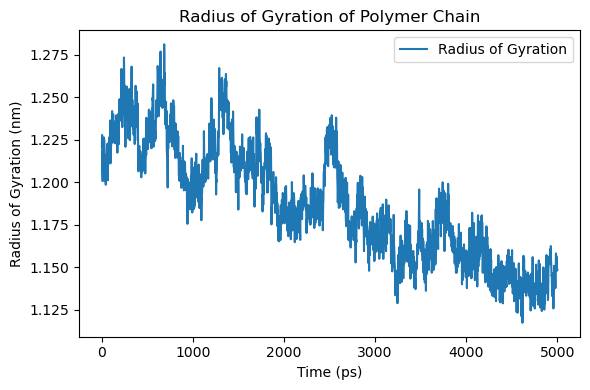

In [23]:
# Plot Radius of Gyration
gyrate_data = np.loadtxt(f"{analysis_dir}/gyrate.xvg", comments=["@", "#"])
time = gyrate_data[:, 0]  # Time (ps)
rg = gyrate_data[:, 1]    # Radius of Gyration (nm)

plt.figure(figsize=(6, 4))
plt.plot(time, rg, label="Radius of Gyration")
plt.xlabel("Time (ps)")
plt.ylabel("Radius of Gyration (nm)")
plt.title("Radius of Gyration of Polymer Chain")
plt.legend()
plt.tight_layout()
plt.show()

Changed to simulation directory: /Users/harish/Documents/Work_folder/MetaChem-workshops/polymermd-workshop/Day4-gmx-md-formats/simulations/PEO25_PET25_block/analysis
Changed to simulation directory: /Users/harish/Documents/Work_folder/MetaChem-workshops/polymermd-workshop/Day4-gmx-md-formats/simulations/PEO25_PET25_random/analysis


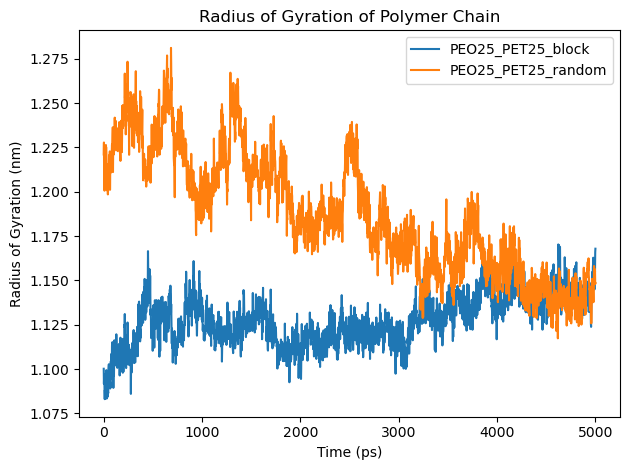

In [24]:
# Plot Rg of both block and random co-polymers
# Looping through both the polymer names and set the directories accordingly
for polymer_name in ['PEO25_PET25_block','PEO25_PET25_random']:
    analysis_dir = set_simulation_directory(polymer_name, "analysis")
    gyrate_data = np.loadtxt(f"{analysis_dir}/gyrate.xvg", comments=["@", "#"])
    time = gyrate_data[:, 0]  # Time (ps)
    rg = gyrate_data[:, 1]    # Radius of Gyration (nm)
    
    plt.plot(time, rg, label=polymer_name)
    plt.xlabel("Time (ps)")
    plt.ylabel("Radius of Gyration (nm)")
plt.title("Radius of Gyration of Polymer Chain")
plt.legend()
plt.tight_layout()
plt.show()

## Radial Distribution Function (RDF)

### Purpose
Calculate the RDF for:
1. Na-Cl ions.
2. Na with Os from the polymer.

### Procedure
1. Use `gmx rdf` to calculate the RDF.

 ```bash
"gmx rdf" calculates radial distribution functions from one reference set of
position (set with -ref) to one or more sets of positions (set with -sel).

To set the bin width and maximum distance to use in the RDF, use -bin and
-rmax, respectively. The latter can be used to limit the computational cost if
the RDF is not of interest up to the default (half of the box size with PBC,
three times the box size without PBC).

The RDFs are normalized by 1) average number of positions in -ref (the number
of groups with -surf), 2) volume of the bin, and 3) average particle density
of -sel positions for that selection. 

Option -cn produces the cumulative number RDF, i.e. the average number of
particles within a distance r.

```
2. The command will ask to select two groups, one for reference and another for selection. For eample, if reference is NA (Group 4) and selection is CL (Group 5), this will output the RDF of Cl- around Na+. The output should look like this:

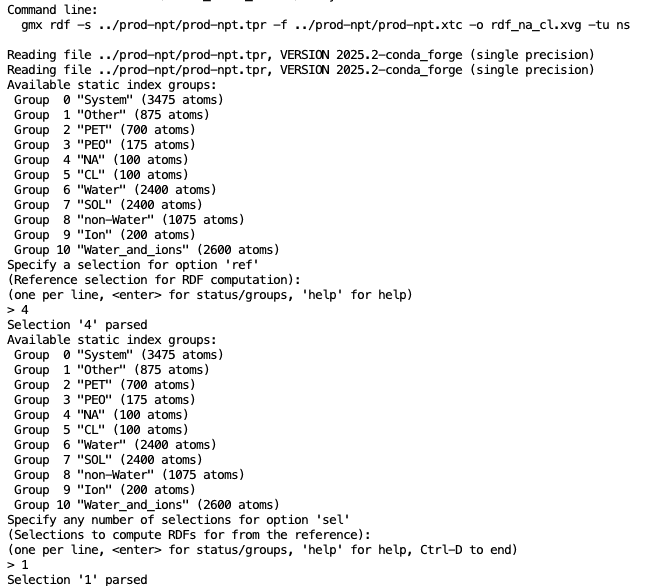

3. Plot the RDF as a function of distance from **ANALYSIS_DIR/rdf.xvg**.

In [16]:
# Set the directories
polymer_name = "PEO25_PET25_random"
analysis_dir = set_simulation_directory(polymer_name, "analysis")

# Calculate RDF for Na-Cl
rdf_na_cl_cmd = "gmx rdf -s ../prod-npt/prod-npt.tpr -f ../prod-npt/prod-npt.xtc -o rdf_na_cl.xvg -cn cn_na_cl.xvg -tu ns"
print(f"Run this command in external terminal to calculate RDF for Na-Cl: \n {rdf_na_cl_cmd}")

# Calculate RDF for water-polymer
rdf_water_pol_cmd = "gmx rdf -s ../prod-npt/prod-npt.tpr -f ../prod-npt/prod-npt.xtc -o rdf_water_pol.xvg -cn cn_water_pol.xvg -tu ns"
print(f"Run this command in external terminal to calculate RDF for Water-Polymer: \n {rdf_water_pol_cmd}")

# Calculate RDF for water-water
rdf_water_water_cmd = "gmx rdf -s ../prod-npt/prod-npt.tpr -f ../prod-npt/prod-npt.xtc -o rdf_water_water.xvg -cn cn_water_water.xvg -tu ns"
print(f"Run this command in external terminal to calculate RDF for Water-Water: \n {rdf_water_water_cmd}")


Changed to simulation directory: /Users/harish/Documents/Work_folder/MetaChem-workshops/polymermd-workshop/Day4,5-gmx-md-simulation-analysis/simulations/PEO25_PET25_random/analysis
Run this command in external terminal to calculate RDF for Na-Cl: 
 gmx rdf -s ../prod-npt/prod-npt.tpr -f ../prod-npt/prod-npt.xtc -o rdf_na_cl.xvg -cn cn_na_cl.xvg -tu ns
Run this command in external terminal to calculate RDF for Water-Polymer: 
 gmx rdf -s ../prod-npt/prod-npt.tpr -f ../prod-npt/prod-npt.xtc -o rdf_water_pol.xvg -cn cn_water_pol.xvg -tu ns
Run this command in external terminal to calculate RDF for Water-Water: 
 gmx rdf -s ../prod-npt/prod-npt.tpr -f ../prod-npt/prod-npt.xtc -o rdf_water_water.xvg -cn cn_water_water.xvg -tu ns


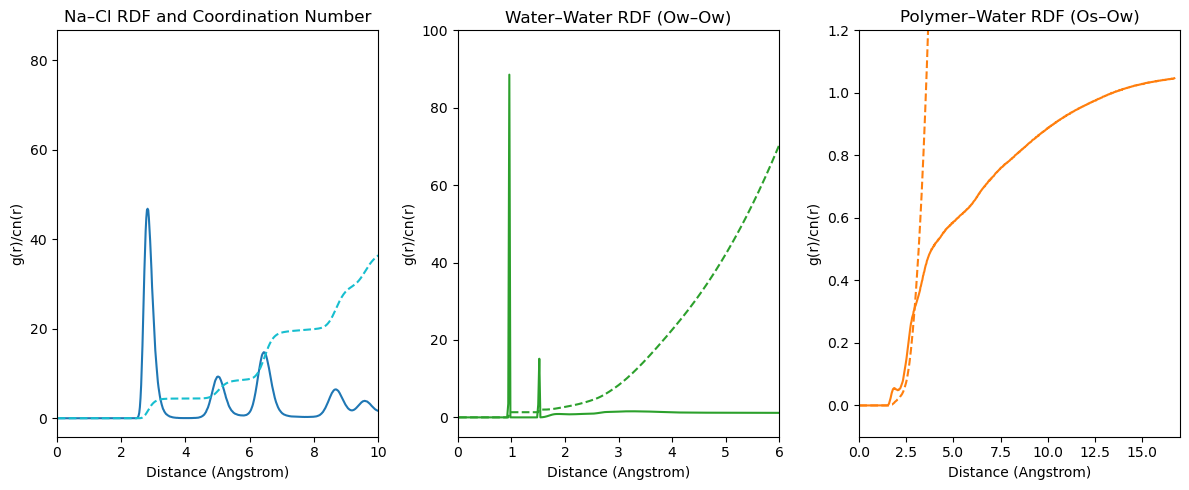

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# Load RDF data
rdf_na_cl = np.loadtxt("rdf_na_cl.xvg", comments=("@", "#"));cn_na_cl = np.loadtxt("cn_na_cl.xvg", comments=("@", "#"))
rdf_ow_ow = np.loadtxt("rdf_water_water.xvg", comments=("@", "#")); cn_ow_ow = np.loadtxt("cn_water_water.xvg", comments=("@", "#"))
rdf_os_ow = np.loadtxt("rdf_water_pol.xvg", comments=("@", "#")); cn_os_ow = np.loadtxt("cn_water_pol.xvg", comments=("@", "#"))

plt.figure(figsize=(12, 5))

# Na–Cl RDF
plt.subplot(1, 3, 1)
plt.plot(rdf_na_cl[:, 0]*10, rdf_na_cl[:, 1], color="tab:blue")
plt.plot(cn_na_cl[:, 0]*10, cn_na_cl[:, 1], color="tab:cyan", linestyle="--", label="Coordination Number")
plt.xlim(0, 10);
plt.xlabel("Distance (Angstrom)")
plt.ylabel("g(r)/cn(r)")
plt.title("Na–Cl RDF and Coordination Number")

# Water–Water RDF (Ow–Ow)
plt.subplot(1, 3, 2)
plt.plot(rdf_ow_ow[:, 0]*10, rdf_ow_ow[:, 1], color="tab:green")
plt.plot(cn_ow_ow[:, 0]*10, cn_ow_ow[:, 1], color="tab:green", linestyle="--", label="Coordination Number")
plt.xlim(0, 6);plt.ylim(-5,100)
plt.xlabel("Distance (Angstrom)")
plt.ylabel("g(r)/cn(r)")
plt.title("Water–Water RDF (Ow–Ow)")

# Polymer–Water RDF (Os–Ow)
plt.subplot(1, 3, 3)
plt.plot(rdf_os_ow[:, 0]*10, rdf_os_ow[:, 1], color="tab:orange")
plt.plot(cn_os_ow[:, 0]*10, cn_os_ow[:, 1], color="tab:orange", linestyle="--", label="Coordination Number")
plt.xlim(0, 17);plt.ylim(-0.1,1.2)
plt.xlabel("Distance (Angstrom)")
plt.ylabel("g(r)/cn(r)")
plt.title("Polymer–Water RDF (Os–Ow)")

plt.tight_layout()
plt.show()

## Glass Transition Temperature (from Simulated Annealing Simulations)

### Purpose
Estimate the glass transition temperature ($T_g$) of the polymer system by performing a simulated annealing MD simulation and analyzing the density as a function of temperature.

### Stepwise Procedure

1. **Simulated Annealing MD:**
   - Prepare a GROMACS MDP file with an annealing schedule that gradually cools the system from high to low temperature (e.g., 400 K to 240 K in steps).
   - Run the simulated annealing MD in a new directory (e.g., `tg-npt`) using the equilibrated structure as input.
2. **Extract Temperature and Density:**
   - Use `gmx energy` to extract temperature and density from the annealing simulation's energy file (`annealing.edr`).
   - When prompted, select the appropriate indices for Temperature and Density (e.g., 14 and 21).
3. **Fit Density vs Temperature:**
   - Load the extracted data in Python.
   - Fit two linear regions (high-T and low-T) to the density vs temperature curve.
   - The intersection of these fits gives the estimated glass transition temperature ($T_g$).
   - Plot the data, fits, and $T_g$ for visualization.

---

#### Simulated Annealing MD

In [7]:
# Set up and run simulated annealing in a new directory 'tg-npt'
polymer_name = "PEO25_PET25_random"
tg_dir = set_simulation_directory(polymer_name, "tg-npt")

# Write simulated annealing MDP file in tg-npt directory
annealing_mdp = '''
title                   =  Simulated Annealing NPT

; Run parameters
integrator              = md
nsteps                  = 1000000     ; 2 ns (0.002 ps timestep)
dt                      = 0.002

; Output control
nstxout-compressed      = 5000
nstenergy               = 5000
nstlog                  = 5000

; Bonded parameters
constraints             = h-bonds
constraint_algorithm    = lincs

; Nonbonded settings
cutoff-scheme           = Verlet
rlist                   = 1.2
rvdw                    = 1.2

; Electrostatics settings
coulombtype             = PME
rcoulomb                = 1.2

; Temperature coupling
tcoupl                  = V-rescale
tc-grps                 = System
tau_t                   = 0.1
ref_t                   = 400
annealing               = single
annealing_npoints       = 9
annealing_time          = 0 250 500 750 1000 1250 1500 1750 2000
annealing_temp          = 400 380 340 320 300 280 260 250 240

; Pressure coupling
pcoupl                  = Parrinello-Rahman
pcoupltype              = isotropic
tau_p                   = 2.0
ref_p                   = 1.0
compressibility         = 4.5e-5

; Periodic boundary conditions
pbc                     = xyz

; Velocity generation
gen_vel                 = no
'''
with open('annealing.mdp', 'w') as f:
    f.write(annealing_mdp)

# Prepare input and print commands to run simulation
grompp_cmd = f"gmx grompp -f annealing.mdp -c ../prod-npt/prod-npt.gro -p ../topol.top -o annealing.tpr -maxwarn 2"
run_command(grompp_cmd)
mdrun_cmd = "gmx mdrun -s annealing.tpr -deffnm annealing -v"
print(f"Run these commands in the 'tg-npt' directory to perform simulated annealing:\n{grompp_cmd}\n{mdrun_cmd}")

Changed to simulation directory: /Users/harish/Documents/Work_folder/MetaChem-workshops/polymermd-workshop/Day4,5-gmx-md-simulation-analysis/simulations/PEO25_PET25_random/tg-npt
Executing: gmx grompp -f annealing.mdp -c ../prod-npt/prod-npt.gro -p ../topol.top -o annealing.tpr -maxwarn 2
Setting the LD random seed to -16810209

Generated 78 of the 78 non-bonded parameter combinations

Generated 78 of the 78 1-4 parameter combinations

Excluding 3 bonded neighbours molecule type 'system1'

turning H bonds into constraints...

Excluding 2 bonded neighbours molecule type 'SOL'

turning H bonds into constraints...

Excluding 1 bonded neighbours molecule type 'NA'

turning H bonds into constraints...

Excluding 1 bonded neighbours molecule type 'CL'

turning H bonds into constraints...

Taking velocities from '../prod-npt/prod-npt.gro'
Analysing residue names:
There are:    30      Other residues
There are:   800      Water residues
There are:   200        Ion residues
Analysing residues n

                :-) GROMACS - gmx grompp, 2025.2-conda_forge (-:

Executable:   /Users/harish/miniconda3/envs/polymer_md/bin.ARM_NEON_ASIMD/gmx
Data prefix:  /Users/harish/miniconda3/envs/polymer_md
Working dir:  /Users/harish/Documents/Work_folder/MetaChem-workshops/polymermd-workshop/Day4,5-gmx-md-simulation-analysis/simulations/PEO25_PET25_random/tg-npt
Command line:
  gmx grompp -f annealing.mdp -c ../prod-npt/prod-npt.gro -p ../topol.top -o annealing.tpr -maxwarn 2

Ignoring obsolete mdp entry 'title'
Generating 1-4 interactions: fudge = 0.5
Simulated annealing for group System: Single, 9 timepoints
Time (ps)   Temperature (K)
      0.0      400.0
    250.0      380.0
    500.0      340.0
    750.0      320.0
   1000.0      300.0
   1250.0      280.0
   1500.0      260.0
   1750.0      250.0
   2000.0-     240.0
Number of degrees of freedom in T-Coupling group System is 7622.00

GROMACS reminds you: "You Don't Wanna Know" (Pulp Fiction)



### Extract Temperature and Density

In [ ]:
# Extract temperature and density data using gmx energy
# Run this in the terminal in the annealing simulation directory:
energy_cmd = "gmx energy -f annealing.edr -o temp_density.xvg"
print(f"Run this command in external terminal to extract temperature and density: \n {energy_cmd}")

# When prompted, select the indices for Temperature and Density (e.g., 14 and 21), then press Enter.

### Fit Density vs Temperature

Changed to simulation directory: /Users/harish/Documents/Work_folder/MetaChem-workshops/polymermd-workshop/Day4,5-gmx-md-simulation-analysis/simulations/PEO25_PET25_random/tg-npt


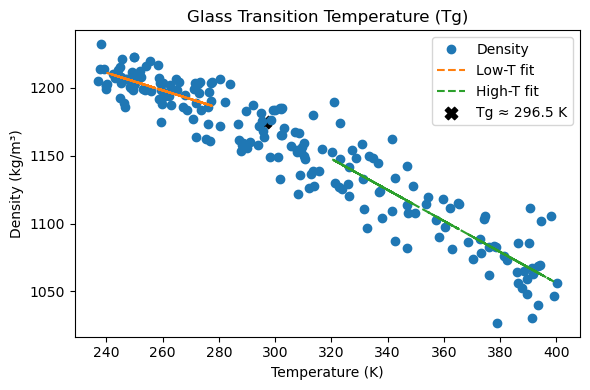

Estimated Tg: 296.52 K


In [29]:
# Fit and plot Density vs Temperature to estimate Tg
# Set up and run simulated annealing in a new directory 'tg-npt'
polymer_name = "PEO25_PET25_random"
tg_dir = set_simulation_directory(polymer_name, "tg-npt")

temp_density_data = np.loadtxt("temp_density.xvg", comments=["@", "#"])
temperature = temp_density_data[:, 1]  # Temperature (K)
density = temp_density_data[:, 2]      # Density (kg/m³)

# Define fitting ranges (adjust indices as needed for your data)
lt_idx0, lt_idx1 = 240, 280  # Low temperature range (K)
ht_idx0, ht_idx1 = 320, 400  # High temperature range (K)

def tg_fit(temp, dens, lt0, lt1, ht0, ht1, lbl='Density'):
    low_mask  = (temp >= lt0) & (temp <= lt1)
    high_mask = (temp >= ht0) & (temp <= ht1)

    if low_mask.sum() < 2 or high_mask.sum() < 2:
        raise ValueError("Not enough points in low-T or high-T range. Adjust ranges.")

    low_t, low_d   = temp[low_mask], dens[low_mask]
    high_t, high_d = temp[high_mask], dens[high_mask]

    m_low, c_low   = np.polyfit(low_t, low_d, 1)
    m_high, c_high = np.polyfit(high_t, high_d, 1)

    tg = (c_low - c_high) / (m_high - m_low)
    rho_tg = m_low * tg + c_low

    plt.plot(temp, dens, 'o', lw=1, label=lbl)
    plt.plot(low_t,  m_low*low_t  + c_low,  '--', label='Low-T fit')
    plt.plot(high_t, m_high*high_t + c_high, '--', label='High-T fit')
    plt.scatter(tg, rho_tg, c='k', marker='X', s=80, label=f'Tg ≈ {tg:.1f} K')

    plt.xlabel("Temperature (K)")
    plt.ylabel("Density (kg/m³)")
    plt.title("Glass Transition Temperature (Tg)")
    plt.legend()
    return tg

plt.figure(figsize=(6, 4))
tg = tg_fit(temperature, density, lt_idx0, lt_idx1, ht_idx0, ht_idx1, lbl='Density')
plt.tight_layout()
plt.show()
print(f"Estimated Tg: {tg:.2f} K")